# Malasanita in Italia - Preanalysis v3 (broad age-standardization 30+)
**Anno 2022 | Fonti: Ministero della Salute (A, C) + ISTAT (D)**

**Domanda:** Le regioni con meno personale sanitario hanno tassi piu alti di mortalita evitabile?

Questa preanalysis usa le stesse 12 cause Euro-2013 della v2, ma sostituisce il proxy grezzo con una **age-standardizzazione broad 30+** su tre bande eta disponibili nella fonte D: `30-69`, `70-84`, `85+`.

Il campo principale e `tasso_std_broad_evitabile_100k_30plus`: tasso standardizzato broad per 100.000, senza denominatore ibrido su popolazione totale.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / 'sources').exists() and (p / 'compose').exists()), None)
if project_root is None:
    raise FileNotFoundError('Non trovo la root di malasanita-struttura-mortalita')

repo_root = project_root.parents[2]
MART_V3 = repo_root / 'out' / 'data' / 'mart' / 'malasanita_a_strutture_asl' / '2022' / 'mart_compose_regioni_v3.parquet'
MART_V2 = repo_root / 'out' / 'data' / 'mart' / 'malasanita_a_strutture_asl' / '2022' / 'mart_compose_regioni_v2.parquet'

df = pd.read_parquet(MART_V3)
df_v2 = pd.read_parquet(MART_V2)
METRIC = 'tasso_std_broad_evitabile_100k_30plus'

print(f'Regioni/PA caricate: {len(df)} | Anno: {df["anno"].iloc[0]}')
print(f'Join C ok: {df["join_c_ok"].sum()}/21 | Join D ok: {df["join_d_ok"].sum()}/21')
print(f'Colonna mortalita: {METRIC}')

Regioni/PA caricate: 21 | Anno: 2022
Join C ok: 21/21 | Join D ok: 21/21
Colonna mortalita: tasso_std_broad_evitabile_100k_30plus


> **Nota metodologica preliminare**
>
> La fonte D non espone classi quinquennali, ma solo tre bande 30+: `30-69`, `70-84`, `85+`.
> La v3 standardizza le 12 cause Euro-2013 su queste tre bande usando pesi ESP2013 aggregati:
> `52.500`, `11.500`, `2.500` (totale `66.500`).
>
> Quindi la v3 e` piu difendibile della v2 grezza per confronto inter-regionale, ma resta piu grossolana di una age-standardization piena a 5 anni.

In [2]:
rank = df[['regione', METRIC, 'personale_osp_per_100k', 'medici_osp_per_100k', 'infermieri_per_100k', 'medici_mmg_per_100k', 'pediatri_per_100k']]\
    .sort_values(METRIC, ascending=False)\
    .reset_index(drop=True)
rank.index = rank.index + 1
rank.head(10)

,regione,tasso_std_broad_evitabile_100k_30plus,personale_osp_per_100k,medici_osp_per_100k,infermieri_per_100k,medici_mmg_per_100k,pediatri_per_100k
1,CAMPANIA,833.2,235.31,136.83,217.37,62.98,12.87
2,SICILIA,742.0,408.50,170.17,294.79,78.58,13.01
3,CALABRIA,722.6,381.09,142.93,283.11,71.14,12.50
4,BASILICATA,697.4,172.40,159.47,185.89,78.35,10.35
5,MOLISE,686.6,836.56,173.54,340.24,82.49,10.95
6,PUGLIA,660.4,303.78,162.33,232.45,76.96,13.13
7,ABRUZZO,656.0,310.75,192.88,426.43,75.71,10.66
8,PIEMONTE,647.4,180.79,149.35,272.56,65.50,8.60
9,LIGURIA,646.3,44.39,211.96,435.19,68.18,10.47
10,LAZIO,635.9,273.67,178.31,236.73,72.53,13.35


In [3]:
corr_cols = ['personale_osp_per_100k', 'medici_osp_per_100k', 'infermieri_per_100k', 'medici_mmg_per_100k', 'pediatri_per_100k', METRIC]
corr = df[corr_cols].corr(numeric_only=True)[METRIC].drop(METRIC).sort_values()
corr.to_frame('corr_con_v3')

,corr_con_v3
medici_osp_per_100k,-0.433848
infermieri_per_100k,0.057977
pediatri_per_100k,0.125768
personale_osp_per_100k,0.213117
medici_mmg_per_100k,0.487561


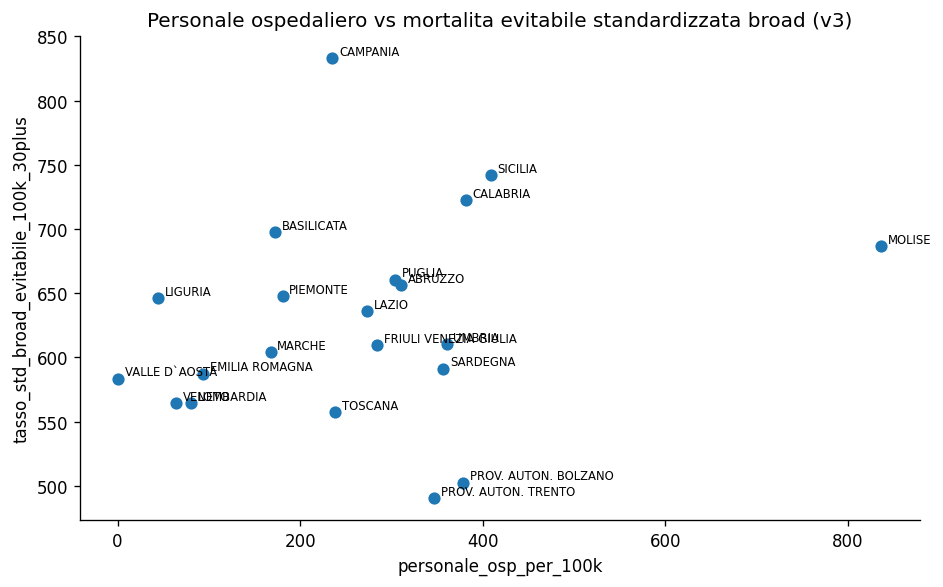

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['personale_osp_per_100k'], df[METRIC], s=40)
for _, r in df.iterrows():
    ax.annotate(r['regione'], (r['personale_osp_per_100k'], r[METRIC]), xytext=(4, 2), textcoords='offset points', fontsize=7)
ax.set_xlabel('personale_osp_per_100k')
ax.set_ylabel(METRIC)
ax.set_title('Personale ospedaliero vs mortalita evitabile standardizzata broad (v3)')
plt.tight_layout()
plt.show()

In [5]:
cmp = df[['regione', 'territorio_istat', METRIC]].merge(
    df_v2[['territorio_istat', 'decessi_evitabili_30plus_per_100k_pop_totale']],
    on='territorio_istat',
    how='left'
)
cmp['rank_v2'] = cmp['decessi_evitabili_30plus_per_100k_pop_totale'].rank(ascending=False, method='min')
cmp['rank_v3'] = cmp[METRIC].rank(ascending=False, method='min')
cmp['delta_rank'] = (cmp['rank_v3'] - cmp['rank_v2']).astype(int)
cmp[['regione', 'rank_v2', 'rank_v3', 'delta_rank']]\
   .sort_values('delta_rank')

,regione,rank_v2,rank_v3,delta_rank
15,CAMPANIA,11.0,1.0,-10
19,SICILIA,10.0,2.0,-8
16,PUGLIA,12.0,6.0,-6
12,LAZIO,15.0,10.0,-5
18,CALABRIA,7.0,3.0,-4
20,SARDEGNA,16.0,14.0,-2
1,VALLE D`AOSTA,17.0,16.0,-1
2,LOMBARDIA,19.0,18.0,-1
3,PROV. AUTON. BOLZANO,21.0,20.0,-1
5,VENETO,18.0,17.0,-1


## Lettura provvisoria

- la v3 non e` una semplice riscrittura della v2: cambia il ranking regionale e riduce il peso della diversa struttura per eta;
- il vantaggio principale rispetto alla v2 e` metodologico: scompare il denominatore ibrido sul totale residenti;
- il limite resta quello della fonte D: tre sole bande eta, quindi standardizzazione broad e non piena.

Il prossimo passo e` decidere se la v3 diventa la baseline consigliata per il confronto inter-regionale, lasciando v2 come proxy grezzo di supporto.